# **Section 10: Feature importance**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# For Venn diagrams
from matplotlib_venn import venn3

# ML imports
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc, roc_auc_score
import xgboost as xgb
import prince

# Set publication-quality style
sns.set_style('whitegrid')
sns.set_palette("pastel")

## 1. Load Data and Results

In [3]:
# Load SNP features and labels
cnv_data = pd.read_csv('cnvs_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = cnv_data.values
y = profiles.values
snp_names = cnv_data.columns.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

# Data split (matching other notebooks)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f'Data loaded: {X.shape[0]} samples, {X.shape[1]} SNP features')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Resistance profiles: {np.unique(y)}')

Data shape: (221, 8085)
Label shape: (221, 1)
Categories: [0 1]
Data loaded: 221 samples, 8085 SNP features
Test set: 67 samples
Resistance profiles: [0 1]


In [5]:
# Load model results
results_df = pd.read_csv('model_results.csv')
print('\nModel Results:')
print(results_df)


Model Results:
                    model                                    hyperparameters  \
0     Logistic Regression                                          C=10.0000   
1     K-Nearest Neighbors                                                k=1   
2  Support Vector Machine                             kernel=poly, C=10.0000   
3           Decision Tree                  max_depth=5, min_samples_split=10   
4                 XGBoost  max_depth=3, learning_rate=0.1, reg_alpha=0.1,...   

   test_accuracy  cv_score  
0       0.985075  0.934839  
1       0.985075  0.928172  
2       0.955224  0.934839  
3       0.880597  0.844516  
4       0.925373  0.928602  


## **2. Feature Importance analysis**

### **2.1 Train All Models with Best Hyperparameters**

In [6]:
# Dictionary to store models and results
models = {}
model_predictions = {}
model_probas = {}

# Logistic Regression
models['Logistic Regression'] = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
models['Logistic Regression'].fit(X_train_total, y_train_total)

# KNN
knn_row = results_df[results_df['model'] == 'K-Nearest Neighbors']
knn_k = int(knn_row['hyperparameters'].values[0].split('k=')[1]) if not knn_row.empty else 5
models['KNN'] = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=knn_k)
)
models['KNN'].fit(X_train_total, y_train_total)

# SVM
svm_row = results_df[results_df['model'] == 'Support Vector Machine']
if not svm_row.empty:
    hyperparams = svm_row['hyperparameters'].values[0]
    svm_kernel = hyperparams.split('kernel=')[1].split(',')[0]
    svm_c = float(hyperparams.split('C=')[1])
else:
    svm_kernel, svm_c = 'linear', 1.0
models['SVM'] = make_pipeline(
    StandardScaler(),
    SVC(kernel=svm_kernel, C=svm_c, probability=True, random_state=42)
)
models['SVM'].fit(X_train_total, y_train_total)

# Get predictions and probabilities
for name, model in models.items():
    model_predictions[name] = model.predict(X_test)
    model_probas[name] = model.predict_proba(X_test)[:, 1]


### **2.2 Permutation importance**

In [7]:
# Calculate feature importance for each model
importances = {}

# Logistic Regression permutation importance
lr_pipe = models['Logistic Regression']
perm_imp_lr = permutation_importance(lr_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances['Logistic Regression'] = perm_imp_lr.importances_mean

knn_pipe = models['KNN']
perm_imp_knn = permutation_importance(knn_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances['KNN'] = perm_imp_knn.importances_mean

# SVM permutation importance
svm_pipe = models['SVM']
perm_imp_svm = permutation_importance(svm_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances['SVM'] = perm_imp_svm.importances_mean

# XGBoost feature importance
# importances['Decision Tree'] = models['Decision Tree'].feature_importances_
# importances['XGBoost'] = models['XGBoost'].feature_importances_

# Get top 200 biomarkers from each model
top_biomarkers = {}
for name, imp in importances.items():
    top_indices = np.argsort(imp)[-200:][::-1]
    top_biomarkers[name] = set(snp_names[top_indices])

print('Top 200 biomarkers identified for each model')

Top 200 biomarkers identified for each model


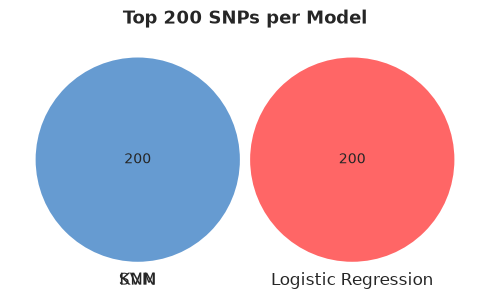

In [8]:
# Create Venn diagram for 3 models
fig, ax = plt.subplots(figsize=(5, 5))

model_list = list(top_biomarkers.keys())
sets = [top_biomarkers[m] for m in model_list]
sns.set_palette("pastel")
# Create 3-way Venn diagram
venn3(sets, set_labels=model_list, ax=ax, alpha=0.6)
ax.set_title('Top 200 SNPs per Model', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('fig06_biomarker_venn.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# All models agree
all_agree = set.intersection(*[top_biomarkers[m] for m in model_list])
print(f'\nSNPs in all 3 models: {len(all_agree)}')
if len(all_agree) > 0:
    print(f'{list(all_agree)[:5]}')

# Pairwise overlaps
print(f'\nPairwise Overlaps:')
for i, m1 in enumerate(model_list):
    for m2 in model_list[i+1:]:
        overlap = len(top_biomarkers[m1] & top_biomarkers[m2])
        jaccard = overlap / len(top_biomarkers[m1] | top_biomarkers[m2])
        print(f'  {m1:20s} ∩ {m2:20s}: {overlap:3d} biomarkers (Jaccard: {jaccard:.3f})')

# Consensus by agreement level
print(f'\nSNPs per model:')
all_snps = set.union(*[top_biomarkers[m] for m in model_list])
for level in range(3, 0, -1):
    consensus = [snp for snp in all_snps if sum([snp in top_biomarkers[m] for m in model_list]) == level]
    print(f'  {level} models agree: {len(consensus):3d} SNPs')


SNPs in all 3 models: 0

Pairwise Overlaps:
  Logistic Regression  ∩ KNN                 :   0 biomarkers (Jaccard: 0.000)
  Logistic Regression  ∩ SVM                 :   0 biomarkers (Jaccard: 0.000)
  KNN                  ∩ SVM                 : 200 biomarkers (Jaccard: 1.000)

SNPs per model:
  3 models agree:   0 SNPs
  2 models agree: 200 SNPs
  1 models agree: 200 SNPs


In [ ]:
### **Signature calculation**